[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Chapters/Advanced/advanced_01_rcts/advanced_01_rcts_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Advanced Module A1 — Randomised Controlled Trials
## Lab: potential outcomes, selection bias, randomisation, regression adjustment, power, peeking

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com). This advanced module extends the book with the Neyman–Rubin causal framework.

**Goal.** Simulate a confounded observational study and watch selection bias flip the sign of a real effect; decompose the naive comparison term by term; verify that randomisation centres the estimator on the truth; adjust a semi-synthetic experiment on the `Wage` data with HC2 errors; plan sample sizes with an analytic power formula checked by simulation; and quantify what peeking does to the Type I error.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition',
               '../../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. A confounded training programme

The deck's running example: $1000$ workers, an optional training programme whose *true* built-in effect is $+4.1$ on average — and a dashboard comparison that says the opposite. Low-skill workers enrol with probability $0.8$, high-skill workers with probability $0.2$, and skill drives wages ($+20$ for high skill), so who takes training is anything but random.

In [2]:
# The simulated population — same seed and draw order as the slides (rng(2024)).
rng = np.random.default_rng(2024)
n = 1000
high   = rng.random(n) < 0.5                    # skill stratum
p_take = np.where(high, 0.2, 0.8)               # self-selection propensities
D      = rng.random(n) < p_take                 # who actually enrols
y0     = 40 + 20*high + rng.normal(0, 5, n)     # potential outcome untreated
tau    = 4 + rng.normal(0, 2, n)                # heterogeneous effects, mean 4
y1     = y0 + tau                               # potential outcome treated
y      = np.where(D, y1, y0)                    # what the dashboard sees

print(f'trained  n={D.sum()},  mean wage {y[D].mean():.1f}')
print(f'untrained n={(~D).sum()}, mean wage {y[~D].mean():.1f}')
print(f'naive difference: {y[D].mean() - y[~D].mean():+.2f}   (true ATE: {tau.mean():+.2f})')

trained  n=491,  mean wage 47.5
untrained n=509, mean wage 55.6
naive difference: -8.07   (true ATE: +4.07)


**Reading the output.** The naive difference says training "costs" $8{,}100$ dollars; the truth built into the simulation is a *gain* of $4{,}070$. The comparison is computed correctly — the causal reading is wrong, because the trained and untrained groups differed before treatment did anything.

low-skill : trained 404 vs 107,  within-stratum diff +3.3
high-skill: trained  87 vs 402,  within-stratum diff +4.8


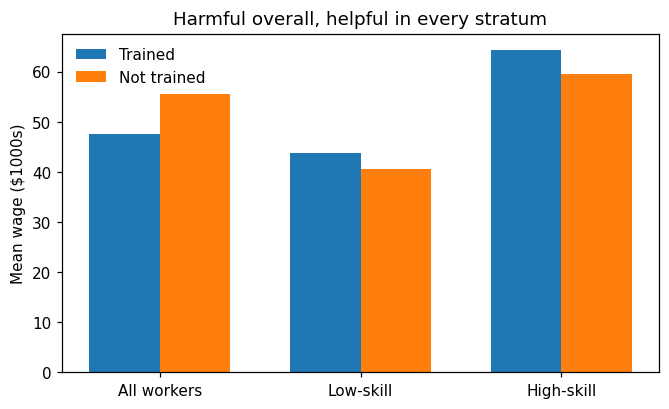

In [3]:
# The sign flips inside every stratum (Simpson's paradox).
for label, mask in [('low-skill ', ~high), ('high-skill', high)]:
    d = y[D & mask].mean() - y[~D & mask].mean()
    print(f'{label}: trained {int((D & mask).sum()):>3} vs {int((~D & mask).sum()):>3},'
          f'  within-stratum diff {d:+.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['All workers', 'Low-skill', 'High-skill']
masks  = [np.ones(n, bool), ~high, high]
x = np.arange(3); w = 0.35
for j, m in enumerate(masks):
    ax.bar(x[j]-w/2, y[D & m].mean(),  w, color='C0', label='Trained'     if j == 0 else None)
    ax.bar(x[j]+w/2, y[~D & m].mean(), w, color='C1', label='Not trained' if j == 0 else None)
ax.set(xticks=x, xticklabels=labels, ylabel='Mean wage ($1000s)',
       title='Harmful overall, helpful in every stratum')
ax.legend(frameon=False)
plt.show()

**How to read the bars.** Overall the trained earn $-8.1$ less; *within* each skill stratum they earn *more* ($+3.3$ low-skill, $+4.8$ high-skill). The aggregate flips sign because $82\%$ of the trained are low-skill against only $21\%$ of the untrained — Simpson's paradox, driven by confounding.

## 2. Potential outcomes and selection bias

Because this is a simulation we hold the God's-eye view: both potential outcomes for everyone. That lets us compute every term of the deck's decomposition

$$\underbrace{E[Y\mid D{=}1]-E[Y\mid D{=}0]}_{\text{naive}} \;=\; \text{ATE} \;+\; \underbrace{E[Y(0)\mid D{=}1]-E[Y(0)\mid D{=}0]}_{\text{selection bias}} \;+\; (1-\pi)\,(\text{ATT}-\text{ATU}).$$

In [4]:
# Every term, computed from the God's-eye view (only a simulation allows this).
naive = y[D].mean() - y[~D].mean()
ATE   = tau.mean()
ATT   = tau[D].mean()
ATU   = tau[~D].mean()
sel   = y0[D].mean() - y0[~D].mean()            # baseline difference
pi    = D.mean()
diff_term = (1 - pi) * (ATT - ATU)

print(f'naive          {naive:+.2f}')
print(f'ATE            {ATE:+.2f}')
print(f'ATT            {ATT:+.2f}   ATU {ATU:+.2f}')
print(f'selection bias {sel:+.2f}')
print(f'diff. effect   {diff_term:+.2f}')
print(f'check: ATE + sel + diff = {ATE + sel + diff_term:+.2f}  (equals the naive difference)')

naive          -8.07
ATE            +4.07
ATT            +3.97   ATU +4.17
selection bias -12.04
diff. effect   -0.10
check: ATE + sel + diff = -8.07  (equals the naive difference)


**Reading the output.** The naive $-8.07$ decomposes exactly: a true effect of $+4.07$, buried under $-12.04$ of selection bias (the trained would have earned far less *anyway*) and a small $-0.10$ differential-effect term. No amount of data shrinks either bias term — only design does.

## 3. Randomisation in action

Same population, two assignment mechanisms, $2000$ replications each: a randomised $500/500$ split against self-selected uptake. We also record how often the Neyman $95\%$ CI $\hat\tau \pm 1.96\,\widehat{\mathrm{SE}}$ covers the true SATE.

In [5]:
# Sampling distribution of the difference in means under both designs.
rng = np.random.default_rng(2024)               # slide seed and draw order
high = rng.random(n) < 0.5
p_take = np.where(high, 0.2, 0.8)
_ = rng.random(n) < p_take                      # the observational draw of Section 1
y0 = 40 + 20*high + rng.normal(0, 5, n)
tau = 4 + rng.normal(0, 2, n)
y1 = y0 + tau

est_r, est_s, cover = [], [], 0
for _i in range(2000):
    Dr = np.zeros(n, bool); Dr[rng.permutation(n)[:500]] = True   # randomised
    yr = np.where(Dr, y1, y0)
    d = yr[Dr].mean() - yr[~Dr].mean(); est_r.append(d)
    se = np.sqrt(yr[Dr].var(ddof=1)/500 + yr[~Dr].var(ddof=1)/500)
    cover += abs(d - tau.mean()) <= 1.96*se                       # CI covers truth?
    Ds = rng.random(n) < p_take                                    # self-selected
    ys = np.where(Ds, y1, y0)
    est_s.append(ys[Ds].mean() - ys[~Ds].mean())
est_r, est_s = np.array(est_r), np.array(est_s)

print(f'randomised    mean {est_r.mean():.2f}  sd {est_r.std():.2f}  CI coverage {cover/2000:.3f}')
print(f'self-selected mean {est_s.mean():.2f}  sd {est_s.std():.2f}  bias {est_s.mean()-tau.mean():+.2f}')
print(f'true SATE {tau.mean():.2f}')

randomised    mean 4.07  sd 0.70  CI coverage 0.951
self-selected mean -7.81  sd 0.56  bias -11.88
true SATE 4.07


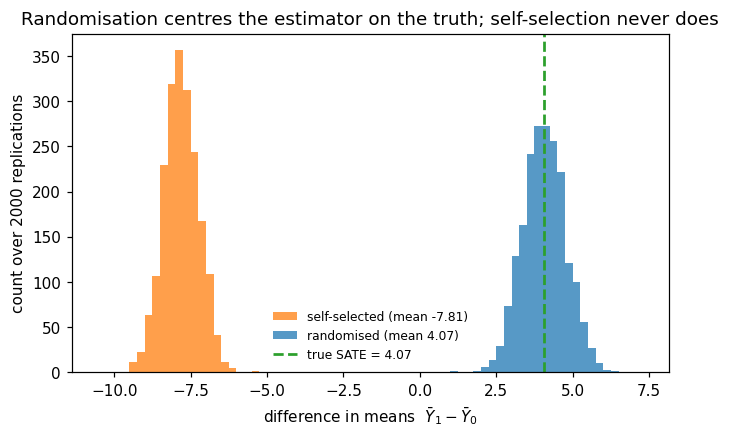

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(-10.5, 7.5, 0.25)
ax.hist(est_s, bins=bins, color='C1', alpha=0.75, label=f'self-selected (mean {est_s.mean():.2f})')
ax.hist(est_r, bins=bins, color='C0', alpha=0.75, label=f'randomised (mean {est_r.mean():.2f})')
ax.axvline(tau.mean(), color='C2', ls='--', lw=1.8, label=f'true SATE = {tau.mean():.2f}')
ax.set(xlabel=r'difference in means  $\bar{Y}_1 - \bar{Y}_0$', ylabel='count over 2000 replications',
       title='Randomisation centres the estimator on the truth; self-selection never does')
ax.legend(frameon=False, fontsize=8)
plt.show()

**Reading the histograms.** Randomised: centred exactly on the truth ($4.07$), sd $0.70$, and the CI covers the truth in $95.1\%$ of draws — the advertised guarantee, delivered. Self-selected: mean $-7.81$, a structural bias of $-11.9$ that repeating the study $2000$ times does not touch. Note the orange histogram is *narrower* — precision is no defence against bias.

## 4. Regression adjustment on Wage

A semi-synthetic experiment on real course data: real covariates and wages from `Wage` ($n = 3000$), a *randomised* fake programme $D$, and a true effect of $+5$ built in by construction. Adjusting for pre-treatment covariates must not change what we estimate — only how precisely.

In [7]:
import statsmodels.formula.api as smf

Wage = load('Wage')                             # course data, n = 3000
rng = np.random.default_rng(2024)               # lecture seed
Wage['D'] = (rng.random(len(Wage)) < 0.5).astype(int)   # coin flip: 1475 vs 1525
Wage['y'] = Wage['wage'] + 5.0*Wage['D']        # truth by construction: tau = +5

m0 = smf.ols('y ~ D', data=Wage).fit(cov_type='HC2')                 # unadjusted
m1 = smf.ols('y ~ D + age + education', data=Wage).fit(cov_type='HC2')  # adjusted

for name, m in [('unadjusted', m0), ('adjusted  ', m1)]:
    lo, hi = m.conf_int().loc['D']
    print(f'{name}  tau_hat {m.params["D"]:.3f}   SE {m.bse["D"]:.3f}   95% CI [{lo:.2f}, {hi:.2f}]')
print(f'variance ratio (adj/unadj): {(m1.bse["D"]/m0.bse["D"])**2:.3f}   R2 of adjusted model: {m1.rsquared:.2f}')

unadjusted  tau_hat 4.122   SE 1.523   95% CI [1.14, 7.11]
adjusted    tau_hat 3.732   SE 1.315   95% CI [1.15, 6.31]
variance ratio (adj/unadj): 0.746   R2 of adjusted model: 0.26


**Reading the output.** Unadjusted: $\hat\tau = 4.122$ (SE $1.523$). Adjusted: $\hat\tau = 3.732$ (SE $1.315$). Both within one SE of the built-in $+5$; the estimates differ only through sampling noise. What changed *systematically* is the SE: the variance fell by $25\%$, so the adjusted analysis of $3000$ people is as precise as an unadjusted one of about $4000$ — precision for free, fuelled by the $R^2 \approx 0.26$ the covariates explain. HC2 errors are the natural default in an experiment: they reproduce the Neyman variance and drop the equal-variance assumption.

## 5. Power

Before launching an experiment: how large must each arm be to detect the effect we care about? The analytic two-arm formula

$$n \;=\; \frac{2\,(z_{1-\alpha/2}+z_{1-\beta})^2\,\sigma^2}{\delta^2}$$

against a simulation that resamples the real `Wage` wages ($\sigma = 41.7$) and plants a $\delta = +5$ effect.

In [8]:
from scipy import stats

sigma = Wage['wage'].std()
delta = 5.0
za = stats.norm.ppf(0.975)
n80 = 2*(za + stats.norm.ppf(0.80))**2 * sigma**2 / delta**2
print(f'sigma = {sigma:.1f};  80% power needs n = {np.ceil(n80):.0f} per arm')

# Simulated power at n = 500: 1000 fake experiments on resampled Wage data.
rng = np.random.default_rng(2024)
w = Wage['wage'].values
rej = 0
for _i in range(1000):
    yc = rng.choice(w, 500)
    yt = rng.choice(w, 500) + delta
    se = np.sqrt(yt.var(ddof=1)/500 + yc.var(ddof=1)/500)
    rej += abs((yt.mean() - yc.mean())/se) > za
analytic500 = (stats.norm.cdf(delta/(sigma*np.sqrt(2/500)) - za)
               + stats.norm.cdf(-delta/(sigma*np.sqrt(2/500)) - za))
print(f'power at n=500:  simulated {rej/1000:.3f}   analytic {analytic500:.3f}')

sigma = 41.7;  80% power needs n = 1094 per arm
power at n=500:  simulated 0.477   analytic 0.474


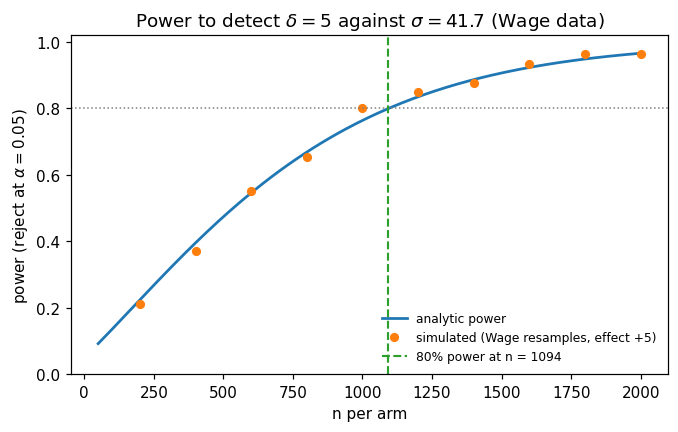

In [9]:
# The full curve: analytic line, simulated dots.
ns = np.arange(50, 2001, 10)
analytic = (stats.norm.cdf(delta/(sigma*np.sqrt(2/ns)) - za)
            + stats.norm.cdf(-delta/(sigma*np.sqrt(2/ns)) - za))
rng = np.random.default_rng(2024)
n_dots = np.arange(200, 2001, 200)
sim = []
for npa in n_dots:
    r = 0
    for _i in range(400):                        # 400 draws per dot keeps this quick
        yc = rng.choice(w, npa); yt = rng.choice(w, npa) + delta
        se = np.sqrt(yt.var(ddof=1)/npa + yc.var(ddof=1)/npa)
        r += abs((yt.mean() - yc.mean())/se) > za
    sim.append(r/400)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, analytic, color='C0', lw=1.8, label='analytic power')
ax.plot(n_dots, sim, 'o', color='C1', ms=5, label='simulated (Wage resamples, effect +5)')
ax.axhline(0.80, color='grey', lw=1, ls=':')
ax.axvline(n80, color='C2', ls='--', lw=1.4, label=f'80% power at n = {np.ceil(n80):.0f}')
ax.set(xlabel='n per arm', ylabel=r'power (reject at $\alpha=0.05$)', ylim=(0, 1.02),
       title=r'Power to detect $\delta = 5$ against $\sigma = 41.7$ (Wage data)')
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.show()

**Reading the curve.** Formula and simulation agree everywhere: at $n=500$ the simulation says $0.477$ against the formula's $0.474$ — a slightly bent coin. Detecting $\delta = 5$ against $\sigma = 41.7$ with $80\%$ power needs $1094$ per arm, and $n \propto 1/\delta^2$: halving the effect you must detect roughly quadruples the sample.

## 6. Peeking

An A/A test — both arms identical, no true effect — checked after every $100$ users per arm and stopped at the first significant result. Each look is another hypothesis test on overlapping data: multiple testing in the time dimension (Chapter 13's problem, wearing a lab coat). Change `step` or `looks` and watch the error rate move.

In [10]:
# Stop-at-first-significance inflates the Type I error (4000 A/A experiments).
rng = np.random.default_rng(2024)
reps, looks, step = 4000, 20, 100
rej_at = np.zeros(looks)
for _i in range(reps):
    a = rng.normal(0, 1, looks*step)             # arm A (no effect anywhere)
    b = rng.normal(0, 1, looks*step)             # arm B
    for k in range(1, looks + 1):
        na = k*step
        z = (a[:na].mean() - b[:na].mean()) / np.sqrt(2/na)
        if abs(z) > 1.96:                        # 'significant' at this look -> stop
            rej_at[k - 1] += 1
            break
cum = np.cumsum(rej_at)/reps
for k in (1, 5, 10, 20):
    print(f'false-positive rate by look {k:>2}: {cum[k-1]:.3f}')

false-positive rate by look  1: 0.046
false-positive rate by look  5: 0.145
false-positive rate by look 10: 0.194
false-positive rate by look 20: 0.243


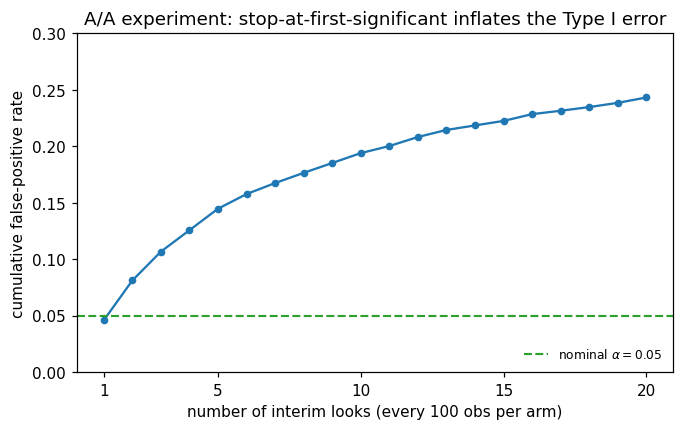

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ks = np.arange(1, looks + 1)
ax.plot(ks, cum, '-o', color='C0', ms=4)
ax.axhline(0.05, color='C2', ls='--', lw=1.4, label=r'nominal $\alpha = 0.05$')
ax.set(xlabel='number of interim looks (every 100 obs per arm)',
       ylabel='cumulative false-positive rate', ylim=(0, 0.30), xticks=[1, 5, 10, 15, 20],
       title='A/A experiment: stop-at-first-significant inflates the Type I error')
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.show()

**Reading the output.** $4.6\%$ after one look — the nominal level — but $14.5\%$ by five looks, $19.4\%$ by ten, $24.3\%$ by twenty: five times $\alpha$. The looks are correlated (overlapping data), so the rate stays below the independent-tests bound $1 - 0.95^{20} = 64\%$, yet a quarter of ineffective changes would ship. Fix the horizon in advance, or pre-specify group-sequential boundaries.

## Lecture exercises — worked Python solutions

These are the **[Python]-tagged exercises from the lecture slides**, solved step by step; run them cell by cell and compare with the slide solutions. Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and on Colab.

### Extended Exercise A1.1 — Randomisation vs selection in simulation [Python]

**Task (from the slides).** Build the training population with `np.random.default_rng(2024)`: `high` $\sim$ Bernoulli($0.5$), enrolment probability $0.8/0.2$ for low/high skill, $Y(0) = 40 + 20\,\texttt{high} + \mathcal N(0,5^2)$, $\tau = 4 + \mathcal N(0,2^2)$, $n = 1000$. Then:
1. simulate $2000$ replications of (a) self-selected uptake and (b) randomised $500/500$ assignment;
2. report mean and sd of both estimator distributions, and the bias of (a);
3. under randomisation, compute the coverage of the $95\%$ CI $\hat\tau \pm 1.96\,\widehat{\mathrm{SE}}$;
4. in two sentences: what does randomisation fix, and what does it not fix?

In [12]:
# (1)-(3) ---------------------------------------------------------------
rng = np.random.default_rng(2024)                # module seed
n = 1000
high = rng.random(n) < 0.5                       # skill stratum
p_sel = np.where(high, 0.2, 0.8)                 # self-selection propensities
_ = rng.random(n) < p_sel                        # the observational draw
y0 = 40 + 20*high + rng.normal(0, 5, n)          # potential outcome untreated
tau = 4 + rng.normal(0, 2, n)                    # heterogeneous ITEs, mean 4
y1 = y0 + tau                                    # potential outcome treated

est_r, est_s, cover = [], [], 0
for _i in range(2000):                           # 2000 replications
    Dr = np.zeros(n, bool); Dr[rng.permutation(n)[:500]] = True   # randomised
    yr = np.where(Dr, y1, y0)
    d = yr[Dr].mean() - yr[~Dr].mean(); est_r.append(d)
    se = np.sqrt(yr[Dr].var(ddof=1)/500 + yr[~Dr].var(ddof=1)/500)
    cover += abs(d - tau.mean()) <= 1.96*se      # CI covers truth?
    Ds = rng.random(n) < p_sel                   # self-selected uptake
    ys = np.where(Ds, y1, y0)
    est_s.append(ys[Ds].mean() - ys[~Ds].mean())
est_r, est_s = np.array(est_r), np.array(est_s)

print(f'true SATE = {tau.mean():.2f}')
print(f'randomised     mean {est_r.mean():.2f}   sd {est_r.std():.2f}   coverage {cover/2000:.3f}')
print(f'self-selected  mean {est_s.mean():.2f}   sd {est_s.std():.2f}   bias {est_s.mean()-tau.mean():.2f}')
# Expected: randomised mean 4.07 sd 0.70 coverage 0.951 ; self-selected mean -7.81 sd 0.56 bias -11.88

true SATE = 4.07
randomised     mean 4.07   sd 0.70   coverage 0.951
self-selected  mean -7.81   sd 0.56   bias -11.88


**(4) Interpretation.** Randomisation removes *bias* — both decomposition terms are zero in expectation, and the Neyman CI covers the truth in $95.1\%$ of draws. It does not remove *variance*: a single unlucky draw can still be off, which is what the SE and CI quantify; nor does it buy SUTVA or fix attrition and non-compliance. And note the trap the slides flag: the self-selected estimator is *more* stable (sd $0.56$ vs $0.70$) — a tight interval around the wrong number is the most dangerous output in statistics.

### Exercise A1.4 — Regression adjustment on the Wage experiment [Python]

**Task (from the slides).** Using `Wage` and the semi-synthetic experiment from the lecture (seed $2024$, coin-flip $D$, $y = \texttt{wage} + 5D$):
1. fit the unadjusted model `y ~ D` with HC2 standard errors and report $\hat\tau$ and its SE;
2. add `age` and `education`; report the new $\hat\tau$ and SE;
3. compute the implied variance reduction and the equivalent sample-size gain;
4. a colleague proposes also adjusting for a satisfaction survey answered *after* the programme — why must you refuse?

In [13]:
# (1)-(2) ---------------------------------------------------------------
Wage = load('Wage')                              # n = 3000
rng = np.random.default_rng(2024)                # lecture seed
Wage['D'] = (rng.random(len(Wage)) < 0.5).astype(int)
Wage['y'] = Wage['wage'] + 5.0*Wage['D']         # true effect +5

m0 = smf.ols('y ~ D', data=Wage).fit(cov_type='HC2')
m1 = smf.ols('y ~ D + age + education', data=Wage).fit(cov_type='HC2')
print(round(m0.params['D'], 3), round(m0.bse['D'], 3))   # Expected: 4.122 1.523
print(round(m1.params['D'], 3), round(m1.bse['D'], 3))   # Expected: 3.732 1.315

# (3) --------------------------------------------------------------------
ratio = (m1.bse['D']/m0.bse['D'])**2
print(f'variance ratio {ratio:.3f}  ->  variance down {(1-ratio)*100:.1f}%,'
      f'  equivalent sample gain x{1/ratio:.2f}')

4.122 1.523
3.732 1.315
variance ratio 0.746  ->  variance down 25.4%,  equivalent sample gain x1.34


**(4) Interpretation.** The survey is **post-treatment**: the programme may change satisfaction, so conditioning on it splits the sample by a *consequence* of $D$ — a "bad control" that re-introduces exactly the selection bias randomisation eliminated. Only pre-treatment covariates are admissible. And resist reading $\hat\tau$ moving from $4.12$ to $3.73$ as "finding a smaller effect": both estimate the same $\tau$; the systematic change is the SE, which is the whole point of adjusting.

## 7. Exercises

1. In Section 3, shrink the randomised arms from $500/500$ to $100/100$. How do the sd of the estimator and the CI coverage respond?
2. Re-run the peeking simulation of Section 6 with a look after every $500$ users per arm (4 looks in total). How much of the inflation survives?
3. In Section 4, add `year` and `jobclass` to the adjustment set. Does the SE fall further? Compare the gain with what `age + education` bought.
4. Using Section 5's formula, how large must each arm be to detect $\delta = 2$ (instead of $5$) with $80\%$ power on the Wage population — and what does that say about "small but real" effects?